# Настройки и Подготовка Датасетов

In [1]:
import os
import urllib.request
import tarfile

os.environ['PYTHONPATH'] = r"E:\data\PROJECT_4\magenta"
ckpt_dir = r"E:\data\PROJECT_4\checkpoints"
local_train_dir = r"E:\data\PROJECT_4\training_runs_mini"

print("Какую модель использовать для генерации?")
print("1 - модель Google")
print("2 - локальная модель (Потребуется обучение если не создана)")
choice = input("Введите 1 или 2: ").strip()

needs_training = False

if choice == '1':
    pre_trained_ckpt = os.path.join(ckpt_dir, "model.ckpt")
    if not os.path.exists(pre_trained_ckpt + ".index"):
        print("Скачиваем официальную модель Magenta...")
        url = "https://storage.googleapis.com/download.magenta.tensorflow.org/models/arbitrary_style_transfer.tar.gz"
        archive_path = os.path.join(ckpt_dir, "arbitrary_style_transfer.tar.gz")
        urllib.request.urlretrieve(url, archive_path)
        with tarfile.open(archive_path, "r:gz") as tar:
            tar.extractall(path=ckpt_dir)
        os.remove(archive_path)
        print("Модель загружена!")
    else:
        print("чекпоинт Google найден и готов к работе.")

elif choice == '2':
    if not os.path.exists(os.path.join(local_train_dir, "checkpoint")):    # TensorFlow  создает системный файл с именем "checkpoint" в папке обучения

        needs_training = True
        print("Локальная модель не найдена. Потребуется запуск обучения!")
    else:
        print("Локально обученный чекпоинт найден и готов к работе!")
else:
    raise ValueError("ошибка!")

Какую модель использовать для генерации?
1 - модель Google
2 - локальная модель (Потребуется обучение если не создана)
Локально обученный чекпоинт найден и готов к работе!


Выбрана локальная модель без предварительного ее создания

# Этап 2: Локальное обучение (Запускается автоматически, если нет локальных весов)

In [2]:
import shutil

if needs_training:
    train_script = r"E:\data\PROJECT_4\magenta\magenta\models\arbitrary_image_stylization\arbitrary_image_stylization_train.py"
    content_dir = r"E:\data\PROJECT_4\tfrecords\coco" 
    style_tf = r"E:\data\PROJECT_4\tfrecords\wikiart\train-mini_wikiart.tfrecord"
    vgg_ckpt = r"E:\data\PROJECT_4\checkpoints\vgg_16.ckpt"
    inception_ckpt = r"E:\data\PROJECT_4\checkpoints\inception_v3.ckpt"
    
    if os.path.exists(local_train_dir):
        shutil.rmtree(local_train_dir)
    os.makedirs(local_train_dir, exist_ok=True)
    
    print("Запускаем обучение на данных ...") # (Осторожно: риск переполнения RAM - старые библиотеки не знакомы с новыми видеокартами! делает все процессор и RAM
    train_cmd = (f'python "{train_script}" '
                 f'--train_dir="{local_train_dir}" '
                 f'--style_dataset_file="{style_tf}" '
                 f'--imagenet_data_dir="{content_dir}" '
                 f'--vgg_checkpoint="{vgg_ckpt}" '
                 f'--inception_v3_checkpoint="{inception_ckpt}" '
                 f'--train_steps=1000 --batch_size=1 --image_size=256') # всего 1000 тк старые версии не поддерживают мою CUDA=>долго
                 
    !set CUDA_VISIBLE_DEVICES=-1&& set TMP=E:\data\PROJECT_4\temp&& set TEMP=E:\data\PROJECT_4\temp&& {train_cmd}
    print("Обучение завершено!")
else:
    print("Обучение не требуется, генерация.")

Обучение не требуется, генерация.


# Этап 3: Инференс (Генерация стилизованных изображений)

 Генерация моделью Google (TFLite)

TFLite модели уже загружены.
 генерация интерполяционных сеток ...


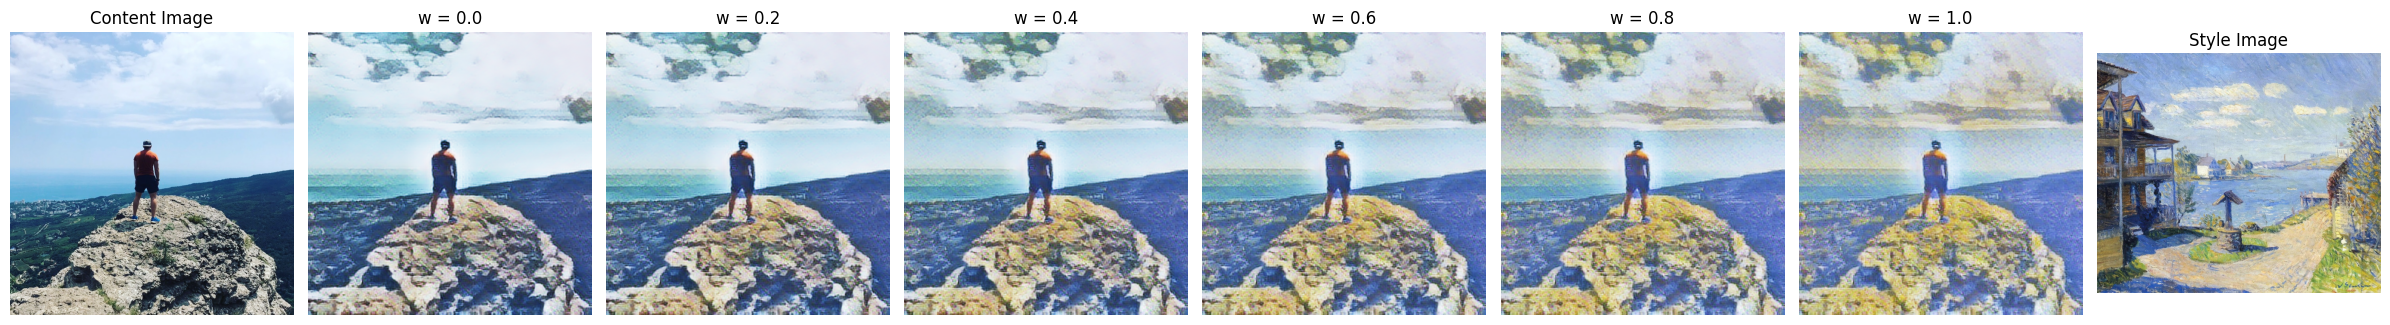

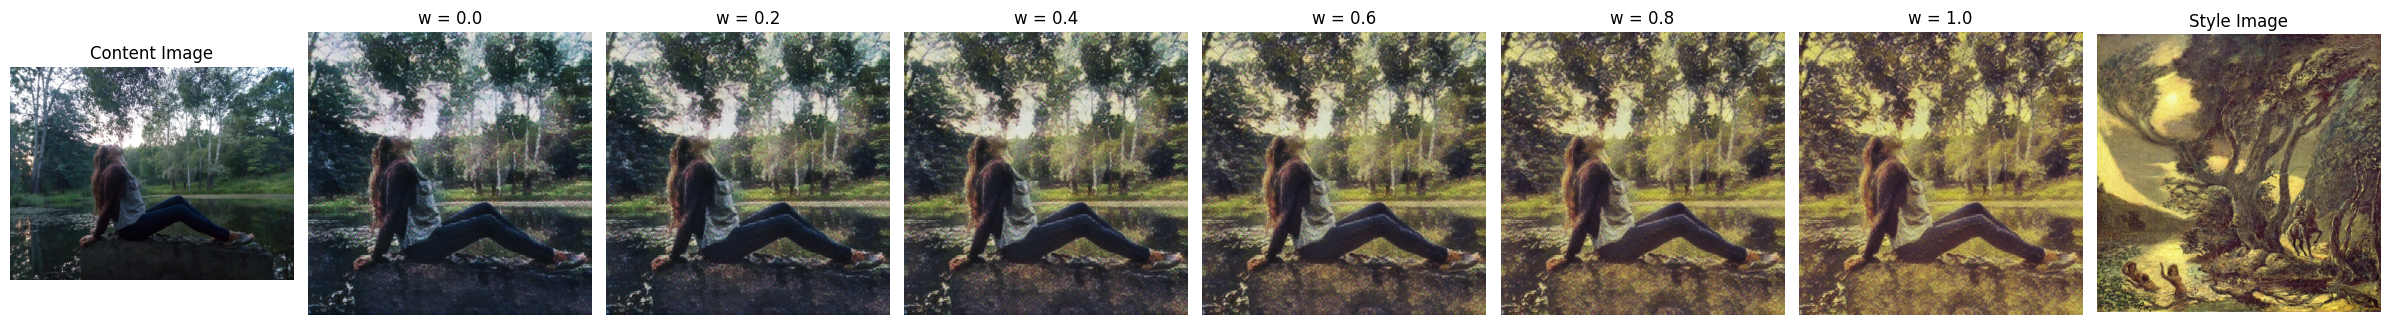

In [3]:
import os
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
import glob
import shutil
from IPython.display import display

print("========================================================")
print(" Генерация моделью Google (TFLite)")
print("========================================================\n")

tflite_dir = r"E:\data\PROJECT_4\tflite_models"  
os.makedirs(tflite_dir, exist_ok=True)

predict_model_path = os.path.join(tflite_dir, "style_predict.tflite")
transfer_model_path = os.path.join(tflite_dir, "style_transfer.tflite")

if not os.path.exists(predict_model_path) or not os.path.exists(transfer_model_path):
    urllib.request.urlretrieve("https://tfhub.dev/google/lite-model/magenta/arbitrary-image-stylization-v1-256/fp16/prediction/1?lite-format=tflite", predict_model_path)
    urllib.request.urlretrieve("https://tfhub.dev/google/lite-model/magenta/arbitrary-image-stylization-v1-256/fp16/transfer/1?lite-format=tflite", transfer_model_path)
    print("Модели скачаны!")
else:
    print("TFLite модели уже загружены.")

predict_interp = tf.lite.Interpreter(model_path=predict_model_path)
predict_interp.allocate_tensors()
transfer_interp = tf.lite.Interpreter(model_path=transfer_model_path)
transfer_interp.allocate_tensors()

def load_and_preprocess(img_path, size):
    img = Image.open(img_path).convert('RGB')
    w, h = img.size
    min_dim = min(w, h)
    left = (w - min_dim) / 2
    top = (h - min_dim) / 2
    right = (w + min_dim) / 2
    bottom = (h + min_dim) / 2
    img = img.crop((left, top, right, bottom))
    img = img.resize((size, size), Image.LANCZOS)
    img_array = np.array(img, dtype=np.float32) / 255.0
    return np.expand_dims(img_array, axis=0)

def run_tflite_interpolation(content_path, style_path):
    style_img = load_and_preprocess(style_path, 256)
    content_img_256 = load_and_preprocess(content_path, 256)
    content_img_384 = load_and_preprocess(content_path, 384)

    predict_interp.set_tensor(predict_interp.get_input_details()[0]['index'], style_img)
    predict_interp.invoke()
    style_bottleneck = predict_interp.get_tensor(predict_interp.get_output_details()[0]['index'])

    predict_interp.set_tensor(predict_interp.get_input_details()[0]['index'], content_img_256)
    predict_interp.invoke()
    content_bottleneck = predict_interp.get_tensor(predict_interp.get_output_details()[0]['index'])

    weights = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
    generated_images = []
    
    for w in weights:
        blended_bottleneck = content_bottleneck * (1 - w) + style_bottleneck * w
        transfer_interp.set_tensor(transfer_interp.get_input_details()[0]['index'], content_img_384)
        transfer_interp.set_tensor(transfer_interp.get_input_details()[1]['index'], blended_bottleneck)
        transfer_interp.invoke()
        
        out_tensor = transfer_interp.get_tensor(transfer_interp.get_output_details()[0]['index'])
        out_image = np.clip(out_tensor[0], 0.0, 1.0)
        generated_images.append((w, out_image))
        
    return generated_images

# Твои картинки
pairs = [
    (r"E:\data\PROJECT_4\test_inference\content\my_photo.jpg", r"E:\data\PROJECT_4\test_inference\style\my_style_1.jpg"),
    (r"E:\data\PROJECT_4\test_inference\content\my_photo_2.jpg", r"E:\data\PROJECT_4\test_inference\style\my_style_2.jpg")
]

print(" генерация интерполяционных сеток ...")

for content_path, style_path in pairs:
    results = run_tflite_interpolation(content_path, style_path)
    
    fig, axes = plt.subplots(1, 8, figsize=(24, 4))
    orig_content = Image.open(content_path)
    axes[0].imshow(orig_content)
    axes[0].set_title("Content Image")
    axes[0].axis('off')
    
    for i, (w, img) in enumerate(results):
        axes[i+1].imshow(img)
        axes[i+1].set_title(f"w = {w}")
        axes[i+1].axis('off')
        
    orig_style = Image.open(style_path)
    axes[-1].imshow(orig_style)
    axes[-1].set_title("Style Image")
    axes[-1].axis('off')
    
    plt.tight_layout()
    plt.show()


 Генерация локальной моделью (.ckpt)

Найден локальный чекпоинт: E:\data\PROJECT_4\training_runs_mini\model.ckpt-1000

Отрисовываем сетку для: my_photo.jpg + my_style_1.jpg ...


2026-09-22 12:57:09.073675: W tensorflow/stream_executor/platform/default/dso_loader.cc:55] Could not load dynamic library 'cudart64_100.dll'; dlerror: cudart64_100.dll not found
2026-09-22 12:57:09.073844: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
e:\data\PROJECT_4\magenta_env\lib\site-packages\pydub\utils.py:170: RuntimeWarning: Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work
  warn("Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work", RuntimeWarning)
Instructions for updating:
non-resource variables are not supported in the long term
2026-09-22 12:57:12.109804: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library nvcuda.dll
2026-09-22 12:57:12.157721: E tensorflow/stream_executor/cuda/cuda_driver.cc:318] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2026-09-22 12:57:12.160

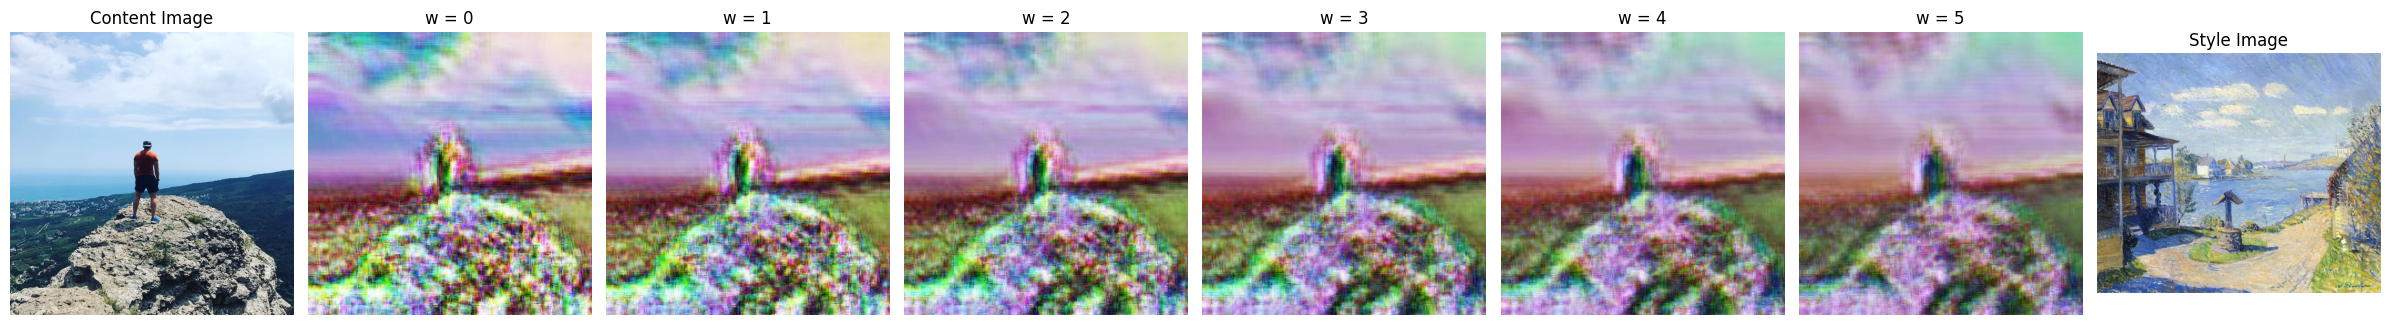


Отрисовываем сетку для: my_photo_2.jpg + my_style_2.jpg ...


2026-09-22 12:57:16.618647: W tensorflow/stream_executor/platform/default/dso_loader.cc:55] Could not load dynamic library 'cudart64_100.dll'; dlerror: cudart64_100.dll not found
2026-09-22 12:57:16.618826: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
e:\data\PROJECT_4\magenta_env\lib\site-packages\pydub\utils.py:170: RuntimeWarning: Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work
  warn("Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work", RuntimeWarning)
Instructions for updating:
non-resource variables are not supported in the long term
2026-09-22 12:57:19.642099: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library nvcuda.dll
2026-09-22 12:57:19.684121: E tensorflow/stream_executor/cuda/cuda_driver.cc:318] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2026-09-22 12:57:19.686

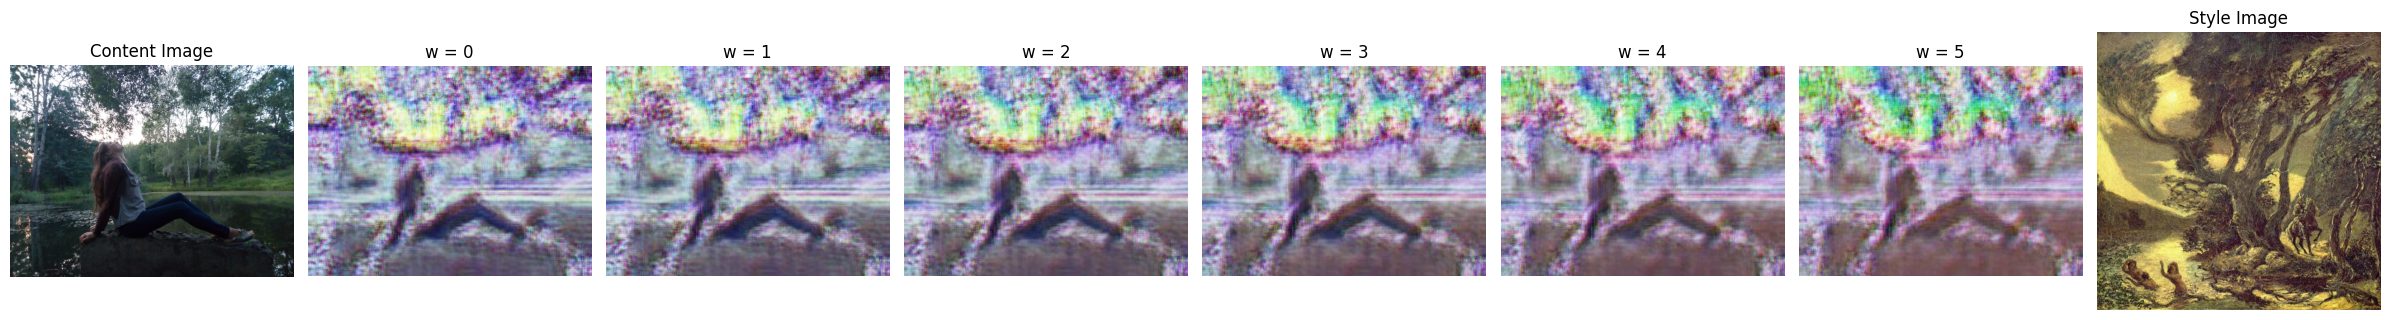

In [5]:
content_1 = r"E:\data\PROJECT_4\test_inference\content\my_photo.jpg"
style_1 = r"E:\data\PROJECT_4\test_inference\style\my_style_1.jpg"
content_2 = r"E:\data\PROJECT_4\test_inference\content\my_photo_2.jpg"
style_2 = r"E:\data\PROJECT_4\test_inference\style\my_style_2.jpg"

pairs = [
    (content_1, style_1),
    (content_2, style_2)
]

print("\n========================================================")
print(" Генерация локальной моделью (.ckpt)")
print("========================================================\n")

local_train_dir = r"E:\data\PROJECT_4\training_runs_mini"
local_ckpt = tf.train.latest_checkpoint(local_train_dir)

if local_ckpt is None:
    print(" Ошибка: В папке training_runs_mini не найдены чекпоинты. Сначала запустите обучение!")
else:
    print(f"Найден локальный чекпоинт: {local_ckpt}")

    eval_script = r"E:\data\PROJECT_4\magenta\magenta\models\arbitrary_image_stylization\arbitrary_image_stylization_with_weights.py"
    out_local = r"E:\data\PROJECT_4\test_inference\output\local_grids"

    if os.path.exists(out_local):
        shutil.rmtree(out_local)
    os.makedirs(out_local, exist_ok=True)

    for content_path, style_path in pairs:
        c_name = os.path.basename(content_path)
        s_name = os.path.basename(style_path)
        print(f"\nОтрисовываем сетку для: {c_name} + {s_name} ...")
        
        cmd_local = (f'python "{eval_script}" '
                     f'--checkpoint="{local_ckpt}" '
                     f'--output_dir="{out_local}" '
                     f'--content_images_paths="{content_path}" '
                     f'--style_images_paths="{style_path}" '
                     f'--image_size=256 '
                     f'--content_square_crop=False '
                     f'--style_image_size=256 '
                     f'--style_square_crop=False '
                     f'--interpolation_weights="[0.0,0.2,0.4,0.6,0.8,1.0]"')
        
        !set CUDA_VISIBLE_DEVICES=-1&& set TMP=E:\data\PROJECT_4\temp&& set TEMP=E:\data\PROJECT_4\temp&& {cmd_local}

        c_base = os.path.splitext(c_name)[0]
        s_base = os.path.splitext(s_name)[0]
        pair_files = glob.glob(os.path.join(out_local, f"*{c_base}*{s_base}*.jpg"))
        
        pair_files.sort()

        if not pair_files:
            print("Ошибка: изображения не сгенерировались.")
        else:
            fig, axes = plt.subplots(1, len(pair_files) + 2, figsize=(24, 4))
            
            axes[0].imshow(Image.open(content_path))
            axes[0].set_title("Content Image")
            axes[0].axis('off')
            
            for i, f in enumerate(pair_files):
                weight_str = f.split('_')[-1].replace('.jpg', '')
                axes[i+1].imshow(Image.open(f))
                axes[i+1].set_title(f"w = {weight_str}")
                axes[i+1].axis('off')
                
            axes[-1].imshow(Image.open(style_path))
            axes[-1].set_title("Style Image")
            axes[-1].axis('off')
            
            plt.tight_layout()
            plt.show()

### Вывод по результатам локального обучения: почему есть разница в качестве и что пойдет в релиз

Как видно из сгенерированных интерполяционных сеток, результаты локально обученной модели сильно отличаются от официальной модели Google. Вместо красивого переноса стиля мы видим артефакты и цветовой шум, который почти не меняется при изменении веса w. Причины:

1. **Лимит в 1000 шагов (Proof of Concept)**
Полноценное обучение архитектуры Arbitrary Style Transfer требует от 1 до 3 миллионов итераций. Мы намеренно ограничили процесс ровно 1000 шагами. На этом этапе нейросеть еще ничего не поняла. Несмотря на то что Loss штатно падает с 2,6 млн до 674 тысяч, декодер еще физически не научился отделять геометрию объектов от художественной текстуры. 

2. **Разница в вычислительных мощностях и данных**
Официальная модель Google обучалась на промышленных тензорных кластерах, прогнав через себя множество изображений из датасета ImageNet. Наша локальная модель видела лишь мини-выборку из 350 картинок, обрабатывая их строго поштучно (`batch_size=1`), чтобы избежать фатального переполнения оперативной памяти (OOM), с которым мы столкнулись на полноразмерном датасете.(даже 1 вызывал переполнение RAM, обучение чудом прошло после включения режима экономии энергии)

**Итоги этапа:**
Тем не менее, была доказана работоспособность концепции: 
* Успешно изолировали среду разработки и побороли конфликты старого TensorFlow 1.15.
* конвертировали сырые данные в формат `TFRecord`.
* успешно запустили граф VGG-16 без графического ускорителя (CPU-only).
* сгенерировали собственный чекпоинт обучения.

**Решение для мобильного приложения:**
Конечная цель проекта — удобное мобильное Android-приложение. Поэтому пайплайн локального обучения остается здесь, как доказательство исследования, а **в само мобильное приложение мы интегрируем готовую и легковесную TFLite-модель от Google**, чтобы обеспечить максимальное качество и скорость генерации на смартфонах.